In [1]:
import pandas as pd

df = pd.read_csv('../data/raw_data/car_prices.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
df_cleaned = df.dropna().drop_duplicates()
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Rows removed: 86512


In [ ]:
df_cleaned = df_cleaned.drop(columns=['vin'])
df_cleaned.columns = [
    'Year',         # year
    'Fabricant',    # make
    'Model',        # model
    'Trim',         # trim
    'Body',         # body
    'Transmission', # transmission
    'State',        # state
    'Condition',    # condition
    'Odometer',     # odometer
    'Color',        # color
    'Interior',     # interior
    'Seller',       # seller
    'MMR',          # mmr
    'SellingPrice', # sellingprice
    'SaleDate'      # saledate
]


,Year,Fabricant,Model,Trim,Body,Transmission,State,Condition,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


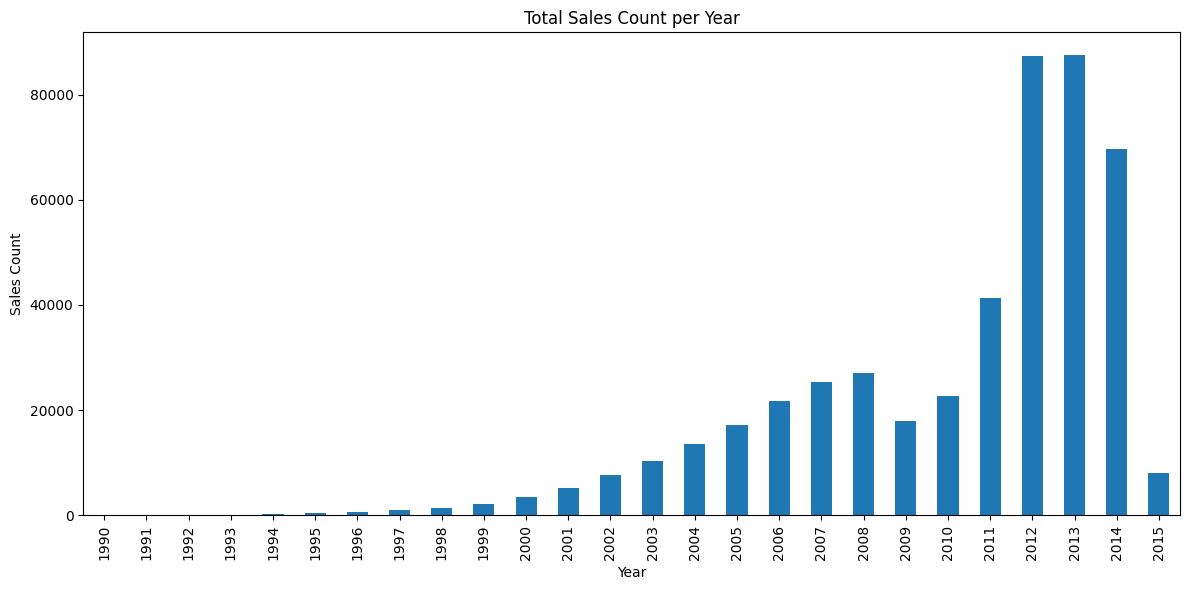

In [8]:
sales_per_year = df_cleaned.groupby('Year').size()
sales_per_year.plot(kind='bar', figsize=(12, 6))
plt.ylabel('Sales Count')
plt.title('Total Sales Count per Year')
plt.tight_layout()
plt.show()


In [10]:
for year, group in df_cleaned.groupby('Year'):
    group.to_csv(f'../data/processed/cars_{year}.csv', index=False)
